# 1. 基础概念

本节介绍变分蒙特卡洛方法的基础概念，包括变分原理、量子多体系统和蒙特卡洛采样基础。

## 1.1 变分蒙特卡洛（VMC）方法简介

变分蒙特卡洛（Variational Monte Carlo, VMC）是一种结合变分原理和蒙特卡洛采样技术的方法，用于求解量子多体系统的基态性质。

### 基本思想

VMC方法的核心思想是：

1. 选择一个包含可调参数的试探波函数$\psi(\mathbf{x}; \mathbf{\theta})$，其中$\mathbf{x}$表示系统组态，$\mathbf{\theta}$表示可调参数
2. 根据变分原理，系统基态能量满足：

$$E_0 \leq \frac{\langle \psi(\mathbf{\theta}) | \hat{H} | \psi(\mathbf{\theta}) \rangle}{\langle \psi(\mathbf{\theta}) | \psi(\mathbf{\theta}) \rangle} = E(\mathbf{\theta})$$

其中$\hat{H}$是系统的哈密顿量，$E(\mathbf{\theta})$是能量期望值

3. 通过优化参数$\mathbf{\theta}$，使能量期望值$E(\mathbf{\theta})$最小化，从而逼近基态能量$E_0$
4. 使用蒙特卡洛方法计算能量期望值及其梯度

### VMC方法的优势

1. **灵活性**：可以处理各种复杂的量子系统，包括强关联系统
2. **可扩展性**：计算复杂度随系统规模增长较慢
3. **精度可控**：通过增加采样次数可以提高计算精度
4. **易于实现**：算法相对简单，易于编程实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Set style for plots
plt.style.use('seaborn-v0_8')
plt.rcParams['font.family'] = 'Arial Unicode MS'  # For Chinese characters
plt.rcParams['axes.unicode_minus'] = False

## 1.2 量子多体系统与波函数

量子多体系统是由多个相互作用的量子粒子组成的系统，如电子、原子、分子等。这些系统的波函数包含了系统的所有信息。

### 波函数的基本性质

1. **归一化条件**：波函数必须满足归一化条件

$$\int |\psi(\mathbf{x})|^2 d\mathbf{x} = 1$$

2. **概率解释**：$|\psi(\mathbf{x})|^2$表示在组态$\mathbf{x}$处找到系统的概率密度

3. **对称性**：对于全同粒子系统，波函数必须满足适当的对称性（费米子反对称，玻色子对称）

### 多体波函数的挑战

1. **维度灾难**：对于$N$个粒子的系统，波函数的维度随$N$指数增长
2. **关联效应**：粒子间的关联效应难以用简单函数描述
3. **计算复杂度**：精确求解多体薛定谔方程的计算复杂度极高

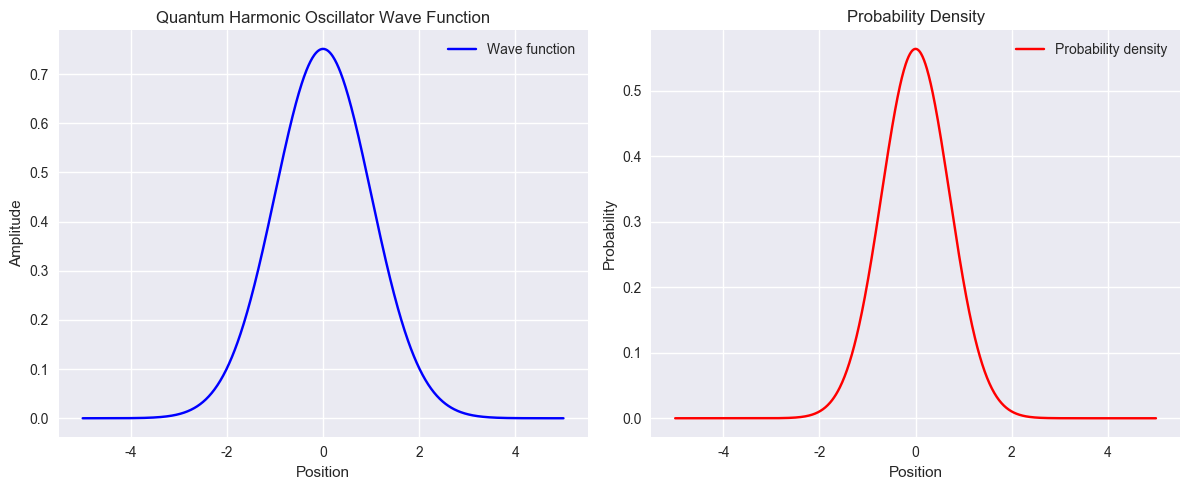

In [2]:
# Example: Wave function for a simple quantum system
def harmonic_oscillator_wavefunction(x, n=0):
    """
    Wave function of quantum harmonic oscillator
    
    Parameters:
    x: position
    n: quantum number (0 for ground state)
    
    Returns:
    Wave function value at position x
    """
    if n == 0:  # Ground state
        return (1/np.pi)**(1/4) * np.exp(-x**2/2)
    else:
        # Higher states would require Hermite polynomials
        raise ValueError("Only ground state (n=0) is implemented")

# Plot wave function
x = np.linspace(-5, 5, 1000)
psi = harmonic_oscillator_wavefunction(x)
probability_density = psi**2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x, psi, 'b-', label='Wave function')
plt.xlabel('Position')
plt.ylabel('Amplitude')
plt.title('Quantum Harmonic Oscillator Wave Function')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x, probability_density, 'r-', label='Probability density')
plt.xlabel('Position')
plt.ylabel('Probability')
plt.title('Probability Density')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 1.3 变分原理在量子系统中的应用

变分原理是量子力学中的基本原理，它为近似求解量子系统提供了理论基础。

### 变分原理的数学表述

对于任意归一化的试探波函数$|\psi\rangle$，系统的能量期望值满足：

$$E = \frac{\langle \psi | \hat{H} | \psi \rangle}{\langle \psi | \psi \rangle} \geq E_0$$

其中$E_0$是系统的基态能量，$\hat{H}$是系统的哈密顿量。

### 变分方法的步骤

1. 选择一个包含可调参数的试探波函数$\psi(\mathbf{x}; \mathbf{\theta})$
2. 计算能量期望值：

$$E(\mathbf{\theta}) = \frac{\int \psi^*(\mathbf{x}; \mathbf{\theta}) \hat{H} \psi(\mathbf{x}; \mathbf{\theta}) d\mathbf{x}}{\int |\psi(\mathbf{x}; \mathbf{\theta})|^2 d\mathbf{x}}$$

3. 通过优化参数$\mathbf{\theta}$，使$E(\mathbf{\theta})$最小化
4. 最小化后的能量$E(\mathbf{\theta}^*)$即为基态能量的上限

### 变分原理的优势

1. **普适性**：适用于任何量子系统
2. **系统性改进**：通过增加试探波函数的灵活性，可以系统性地提高精度
3. **稳定性**：计算过程稳定，不易发散

Optimal alpha: 0.7898
Minimum energy: 0.314401
Exact ground state energy: 0.500000


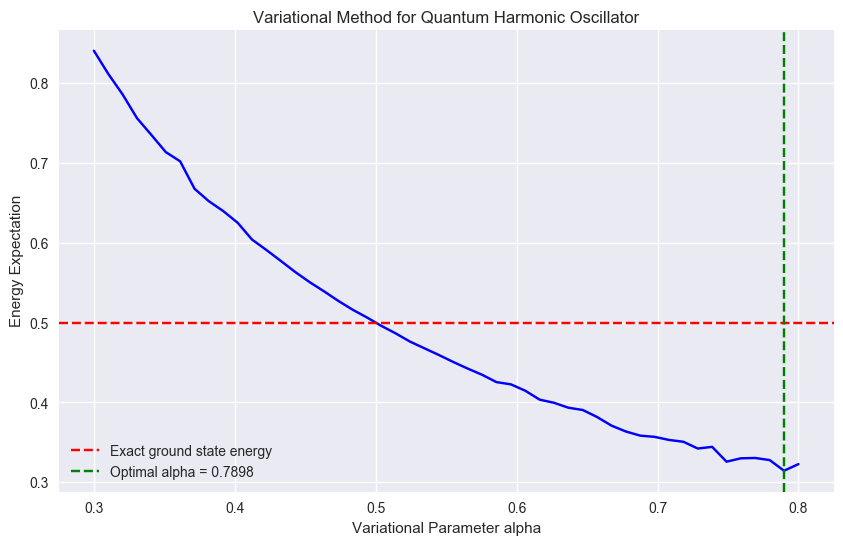

In [3]:
# Example: Variational method for quantum harmonic oscillator
def trial_wavefunction(x, alpha):
    """
    Trial wave function with variational parameter alpha
    
    Parameters:
    x: position
    alpha: variational parameter
    
    Returns:
    Wave function value at position x
    """
    return (2*alpha/np.pi)**(1/4) * np.exp(-alpha * x**2)

def local_energy(x, alpha):
    """
    Local energy for harmonic oscillator
    
    Parameters:
    x: position
    alpha: variational parameter
    
    Returns:
    Local energy at position x
    """
    kinetic = alpha - 2 * alpha**2 * x**2
    potential = 0.5 * x**2
    return kinetic + potential

def energy_expectation(alpha, n_samples=10000):
    """
    Calculate energy expectation using Monte Carlo integration
    
    Parameters:
    alpha: variational parameter
    n_samples: number of Monte Carlo samples
    
    Returns:
    Energy expectation value
    """
    # Generate samples from trial wave function
    sigma = 1/np.sqrt(2*alpha)
    x_samples = np.random.normal(0, sigma, n_samples)
    
    # Calculate local energy at each sample
    e_local = local_energy(x_samples, alpha)
    
    # Energy expectation is average of local energy
    return np.mean(e_local)

# Find optimal alpha
alpha_values = np.linspace(0.3, 0.8, 50)
energies = [energy_expectation(alpha) for alpha in alpha_values]

# Find minimum energy
min_idx = np.argmin(energies)
optimal_alpha = alpha_values[min_idx]
min_energy = energies[min_idx]

print(f"Optimal alpha: {optimal_alpha:.4f}")
print(f"Minimum energy: {min_energy:.6f}")
print(f"Exact ground state energy: {0.5:.6f}")

# Plot energy vs alpha
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, energies, 'b-')
plt.axhline(y=0.5, color='r', linestyle='--', label='Exact ground state energy')
plt.axvline(x=optimal_alpha, color='g', linestyle='--', label=f'Optimal alpha = {optimal_alpha:.4f}')
plt.xlabel('Variational Parameter alpha')
plt.ylabel('Energy Expectation')
plt.title('Variational Method for Quantum Harmonic Oscillator')
plt.legend()
plt.grid(True)
plt.show()

## 1.4 蒙特卡洛采样基础

蒙特卡洛方法是一类通过随机采样来获得数值结果的计算算法。在变分蒙特卡洛中，我们使用蒙特卡洛方法来计算能量期望值及其梯度。

### 蒙特卡洛积分

假设我们要计算积分：

$$I = \int f(x) dx$$

我们可以将其转化为期望值的形式：

$$I = \int \frac{f(x)}{p(x)} p(x) dx = E_p\left[\frac{f(X)}{p(X)}\right]$$

其中$p(x)$是概率密度函数，$X \sim p(x)$。通过从$p(x)$中采样，我们可以估计积分值：

$$I \approx \frac{1}{N}\sum_{i=1}^{N} \frac{f(x_i)}{p(x_i)}$$

### 重要性采样

在变分蒙特卡洛中，我们通常使用波函数的概率密度$|\psi(\mathbf{x}; \mathbf{\theta})|^2$作为采样分布。这样，能量期望值可以表示为：

$$E(\mathbf{\theta}) = \int |\psi(\mathbf{x}; \mathbf{\theta})|^2 E_L(\mathbf{x}; \mathbf{\theta}) d\mathbf{x} = E_{|\psi|^2}[E_L(\mathbf{x}; \mathbf{\theta})]$$

其中$E_L(\mathbf{x}; \mathbf{\theta}) = \frac{\hat{H}\psi(\mathbf{x}; \mathbf{\theta})}{\psi(\mathbf{x}; \mathbf{\theta})}$是局域能量。

通过从$|\psi(\mathbf{x}; \mathbf{\theta})|^2$中采样，我们可以估计能量期望值：

$$E(\mathbf{\theta}) \approx \frac{1}{N}\sum_{i=1}^{N} E_L(\mathbf{x}_i; \mathbf{\theta})$$

### 马尔可夫链蒙特卡洛（MCMC）

由于直接从$|\psi(\mathbf{x}; \mathbf{\theta})|^2$中采样通常很困难，我们使用马尔可夫链蒙特卡洛方法，如Metropolis-Hastings算法，来生成样本。

### 误差分析

蒙特卡洛估计的统计误差通常为$O(1/\sqrt{N})$，其中$N$是样本数。这意味着要将精度提高一个数量级，需要将样本数增加100倍。

In [ ]:
# Example: Monte Carlo integration
def monte_carlo_integration(f, a, b, n_samples=10000):
    """
    Monte Carlo integration of function f from a to b
    
    Parameters:
    f: function to integrate
    a: lower bound
    b: upper bound
    n_samples: number of samples
    
    Returns:
    Integral estimate and standard error
    """
    # Generate uniform random samples
    x = np.random.uniform(a, b, n_samples)
    
    # Evaluate function at samples
    y = f(x)
    
    # Calculate integral estimate
    integral = (b - a) * np.mean(y)
    
    # Calculate standard error
    std_error = (b - a) * np.std(y) / np.sqrt(n_samples)
    
    return integral, std_error

# Example function: sin(x) from 0 to pi
def f(x):
    return np.sin(x)

a, b = 0, np.pi
true_value = 2.0  # Exact integral of sin(x) from 0 to pi

# Calculate with different numbers of samples
sample_sizes = [100, 1000, 10000, 100000]
estimates = []
errors = []
std_errors = []

for n in sample_sizes:
    estimate, std_error = monte_carlo_integration(f, a, b, n)
    error = abs(estimate - true_value)
    estimates.append(estimate)
    errors.append(error)
    std_errors.append(std_error)
    print(f"Samples: {n:7d}, Estimate: {estimate:.6f}, Error: {error:.6f}, Std Error: {std_error:.6f}")

# Plot convergence
plt.figure(figsize=(10, 6))
plt.errorbar(sample_sizes, estimates, yerr=1.96*np.array(std_errors), fmt='o-', label='Monte Carlo Estimate')
plt.axhline(y=true_value, color='r', linestyle='--', label='Exact Value')
plt.xscale('log')
plt.xlabel('Number of Samples')
plt.ylabel('Integral Estimate')
plt.title('Monte Carlo Integration Convergence')
plt.legend()
plt.grid(True)
plt.show()

## 总结

本节介绍了变分蒙特卡洛方法的基础概念，包括：

1. **变分蒙特卡洛方法简介**：VMC方法结合了变分原理和蒙特卡洛采样，用于求解量子多体系统的基态性质

2. **量子多体系统与波函数**：量子多体系统的波函数包含了系统的所有信息，但面临着维度灾难和计算复杂度的挑战

3. **变分原理在量子系统中的应用**：变分原理为近似求解量子系统提供了理论基础，通过优化试探波函数的参数来逼近基态

4. **蒙特卡洛采样基础**：蒙特卡洛方法通过随机采样来计算积分和期望值，是变分蒙特卡洛方法的核心技术

这些基础概念为后续学习基于神经网络的变分蒙特卡洛算法奠定了理论基础。